In [46]:
import pandas as pd

df=pd.read_csv('/Users/gretawette/Documents/Thesis/03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv')

In [47]:
df

,hit_id,row_id,source,Title,hit_text,context_idx,count_hits,count_unique_entities,context_window,model,response_id,category,evidence,raw_response_json
0,d844fe7dbcb4b28a,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,Politico,1,1,1,"Er hat es geschafft, seine Leute überall zu pl...",gpt-5.4-mini,resp_0bd7007a244a3d650069e2b0d797cc8190aca8242...,NEUTRAL,NaN,"{""id"": ""resp_0bd7007a244a3d650069e2b0d797cc819..."
1,f785774b2205e418,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,Bild-Zeitung,1,1,1,Viele haben Reitschuster aus der Corona-Zeit j...,gpt-5.4-mini,resp_0418e7040ed4dbf50069e2b0d7b9488190b15d583...,DISINFORMATION/FALSCHDARSTELLUNG,belügt sie nicht weniger dreist,"{""id"": ""resp_0418e7040ed4dbf50069e2b0d7b948819..."
2,8beba1b1263837c4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,1,1,1,Der Spiegel macht mal wieder Berichterstattung...,gpt-5.4-mini,resp_0f23ef271de158570069e2b0d7354c8196bdd154a...,VERSAGEN/INKOMPETENZ,Berichterstattung für den Kindergarten,"{""id"": ""resp_0f23ef271de158570069e2b0d7354c819..."
3,db28e215f2d3989d,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,2,1,1,Das NABU ist das vielleicht wichtigste Instrum...,gpt-5.4-mini,resp_0d3c4eb8b391ac970069e2b0d7bd7c8190890ffea...,IRRELEVANT,NaN,"{""id"": ""resp_0d3c4eb8b391ac970069e2b0d7bd7c819..."
4,387a8dd7ac2cedde,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,Spiegel,3,4,1,"Ich denke, die Antwort liegt auf der Hand. Mär...",gpt-5.4-mini,resp_095fe284e1d649ed0069e2b0d729308190841c231...,DISINFORMATION/FALSCHDARSTELLUNG,seinen Lesern Märchen erzählt,"{""id"": ""resp_095fe284e1d649ed0069e2b0d72930819..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11970,d5264d5629b3ae25,20436,Tagesschau,Bis zu 100 Sternschnuppen pro Stunde sind möglich,SWR,1,1,1,Rechtzeitig zum neuen Jahr zeigt sich der Ster...,gpt-5.4-mini,resp_01cf98b526336d620069e2e29180208196ae104dc...,NEUTRAL,NaN,"{""id"": ""resp_01cf98b526336d620069e2e2918020819..."
11971,a7bfcc1d5a5e0499,20437,Tagesschau,"Der letzte ""Supermond"" des Jahres",SWR,1,1,1,Und so hoch wie in diesem Jahr wird er wohl la...,gpt-5.4-mini,resp_03e81237abca67cf0069e2e2c505e881959b251c7...,NEUTRAL,NaN,"{""id"": ""resp_03e81237abca67cf0069e2e2c505e8819..."
11972,a3d2ff36023a08a5,20437,Tagesschau,"Der letzte ""Supermond"" des Jahres",SWR,2,2,1,Dezember 2026. SWR Kultur | SWR Impuls | 04.12...,gpt-5.4-mini,resp_065b99645f24d8e10069e2e2c506508196acfac8a...,NEUTRAL,NaN,"{""id"": ""resp_065b99645f24d8e10069e2e2c50650819..."
11973,0049441f9d007ab9,20439,Tagesschau,Projekt zur Tierbeobachtung startet wieder,Deutschlandfunk,1,1,1,"Es war ein paar Mal schon so, dass es wirklich...",gpt-5.4-mini,resp_0876e6e5ab039db20069e2e2c505a081939914f6b...,NEUTRAL,NaN,"{""id"": ""resp_0876e6e5ab039db20069e2e2c505a0819..."


In [48]:
df['category'].value_counts()

category
NEUTRAL                             8837
VERZERRUNG/MANIPULATION             1301
POSITIONS-/PARTEILICHKEITS-BIAS      848
DISINFORMATION/FALSCHDARSTELLUNG     343
VERSAGEN/INKOMPETENZ                 337
IRRELEVANT                           309
Name: count, dtype: int64

In [49]:
df['source'].value_counts()

source
Tagesschau           4370
Tichys_Einblick      2282
Nius                 2026
RT_de                1864
Antispiegel           540
Compact               512
Deutschlandkurier     381
Name: count, dtype: int64

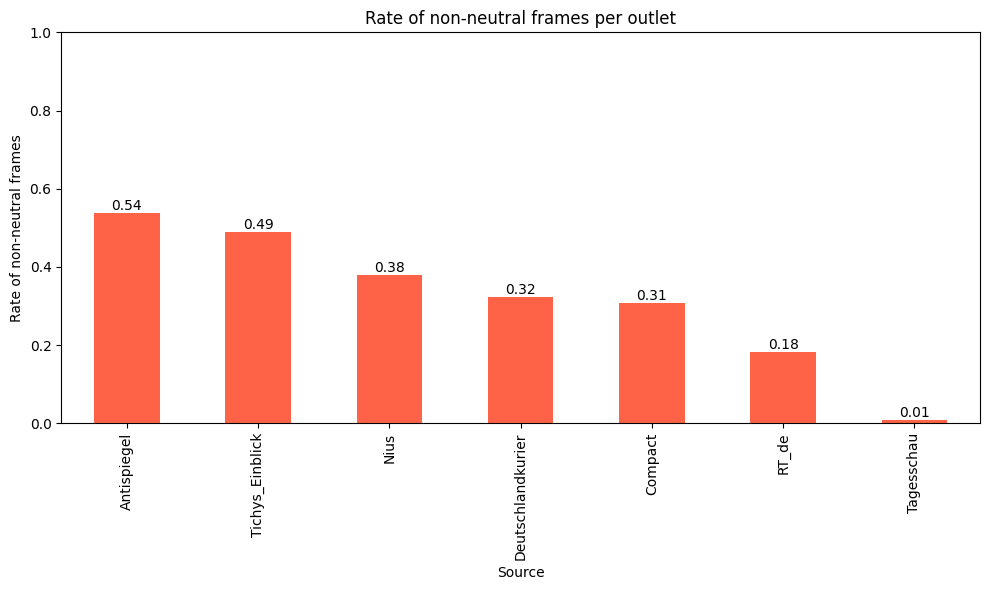

In [50]:
import matplotlib.pyplot as plt

# Normalize potential misspelling
df = df.rename(columns=lambda x: x.strip())
if 'suorce' in df.columns:
    df = df.rename(columns={'suorce': 'source'})
if 'categorty' in df.columns:
    df = df.rename(columns={'categorty': 'category'})

# Compute # non-neutral frames per outlet
non_neutral = df[~df['category'].isin(['NEUTRAL', 'IRRELEVANT'])].groupby('source').size()
total = df.groupby('source').size()
rate = (non_neutral / total).fillna(0).sort_values(ascending=False)

# Plot with bar labels
plt.figure(figsize=(10,6))
ax = rate.plot(kind='bar', color='tomato')
plt.ylabel("Rate of non-neutral frames")
plt.xlabel("Source")
plt.title("Rate of non-neutral frames per outlet")
plt.ylim(0, 1)
plt.tight_layout()

# Add data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}", 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)

plt.show()

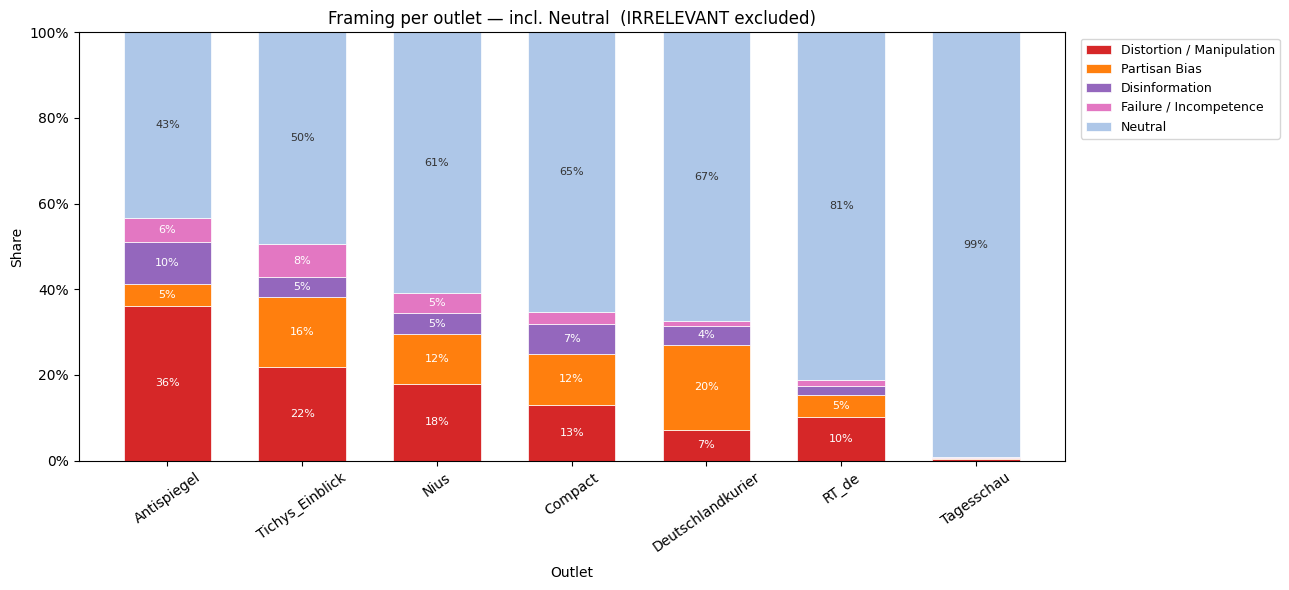

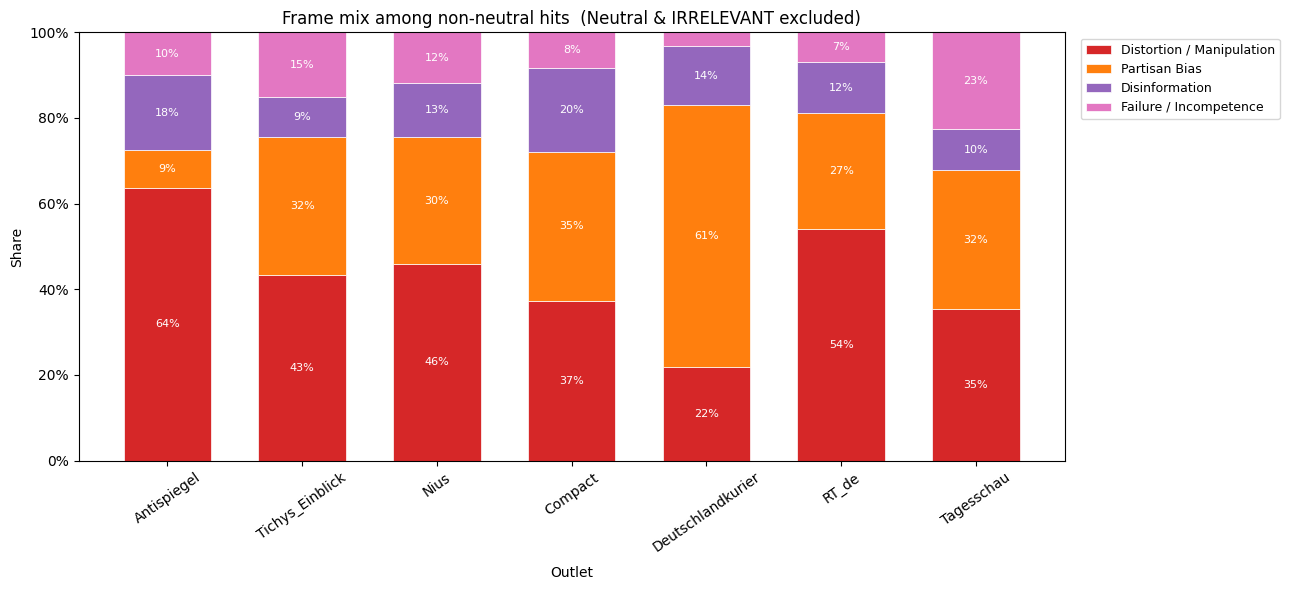

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# ── English labels (IRRELEVANT excluded throughout) ───────────────────────────
CATEGORY_EN = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence",
    "NEUTRAL":                            "Neutral",
}
FRAMING_COLS = [
    "Distortion / Manipulation",
    "Partisan Bias",
    "Disinformation",
    "Failure / Incompetence",
]
COLORS = {
    "Distortion / Manipulation": "#d62728",
    "Partisan Bias":             "#ff7f0e",
    "Disinformation":            "#9467bd",
    "Failure / Incompetence":    "#e377c2",
    "Neutral":                   "#aec7e8",
}

df2 = df.copy()
df2["category_en"] = df2["category"].map(CATEGORY_EN)
df2 = df2.dropna(subset=["category_en"])   # drops IRRELEVANT rows

# ── Helper: draw one stacked 100% bar chart ───────────────────────────────────
def stacked_bar(ax, props, col_order, title):
    bottoms = np.zeros(len(props))
    for frame in col_order:
        vals = props[frame].values
        ax.bar(props.index, vals, bottom=bottoms, color=COLORS[frame],
               label=frame, width=0.65, edgecolor="white", linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.04:
                ax.text(i, b + v / 2, f"{v:.0%}", ha="center", va="center",
                        fontsize=8,
                        color="white" if frame != "Neutral" else "#333")
        bottoms += vals
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_xlabel("Outlet", labelpad=8)
    ax.set_ylabel("Share")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, fontsize=9)

# ── Base counts (IRRELEVANT already gone) ─────────────────────────────────────
ALL_COLS = FRAMING_COLS + ["Neutral"]
counts_all = (
    df2.groupby(["source", "category_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ALL_COLS, fill_value=0)
)

# Sort outlets by total framing share descending (consistent across both charts)
outlet_order = (
    counts_all[FRAMING_COLS].sum(axis=1) / counts_all.sum(axis=1)
).sort_values(ascending=False).index

# ── Chart 1: framing frames + Neutral (100% of non-IRRELEVANT rows) ───────────
props_all = counts_all.div(counts_all.sum(axis=1), axis=0).loc[outlet_order]

fig, ax = plt.subplots(figsize=(13, 6))
stacked_bar(ax, props_all, ALL_COLS, "Framing per outlet — incl. Neutral  (IRRELEVANT excluded)")
plt.tight_layout()
plt.show()

# ── Chart 2: framing frames only (re-normalised among non-neutral rows) ───────
counts_framing = counts_all[FRAMING_COLS].loc[outlet_order]
props_framing  = counts_framing.div(counts_framing.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
stacked_bar(ax, props_framing, FRAMING_COLS,
            "Frame mix among non-neutral hits  (Neutral & IRRELEVANT excluded)")
plt.tight_layout()
plt.show()


## Hit Analysis

In [52]:
# Split combined hit_text entries like "ARD | ZDF | Spiegel" into one row each
df = (
    df.assign(hit_text=df["hit_text"].str.split(r"\s*\|\s*"))
    .explode("hit_text")
    .assign(hit_text=lambda d: d["hit_text"].str.strip())
)

print(f"Rows after splitting combined hits: {len(df)}")
print()
print(df["hit_text"].value_counts().head(20))


Rows after splitting combined hits: 14702

hit_text
Deutschlandfunk    1316
ZDF                1287
Spiegel            1199
ARD                 973
Reuters             750
NDR                 617
SWR                 496
dpa                 489
WDR                 482
Markus Lanz         457
Politico            418
Tagesschau          413
MDR                 371
FAZ                 345
ÖRR                 325
Handelsblatt        304
Stern               301
NDR Info            288
rbb                 287
taz                 285
Name: count, dtype: int64


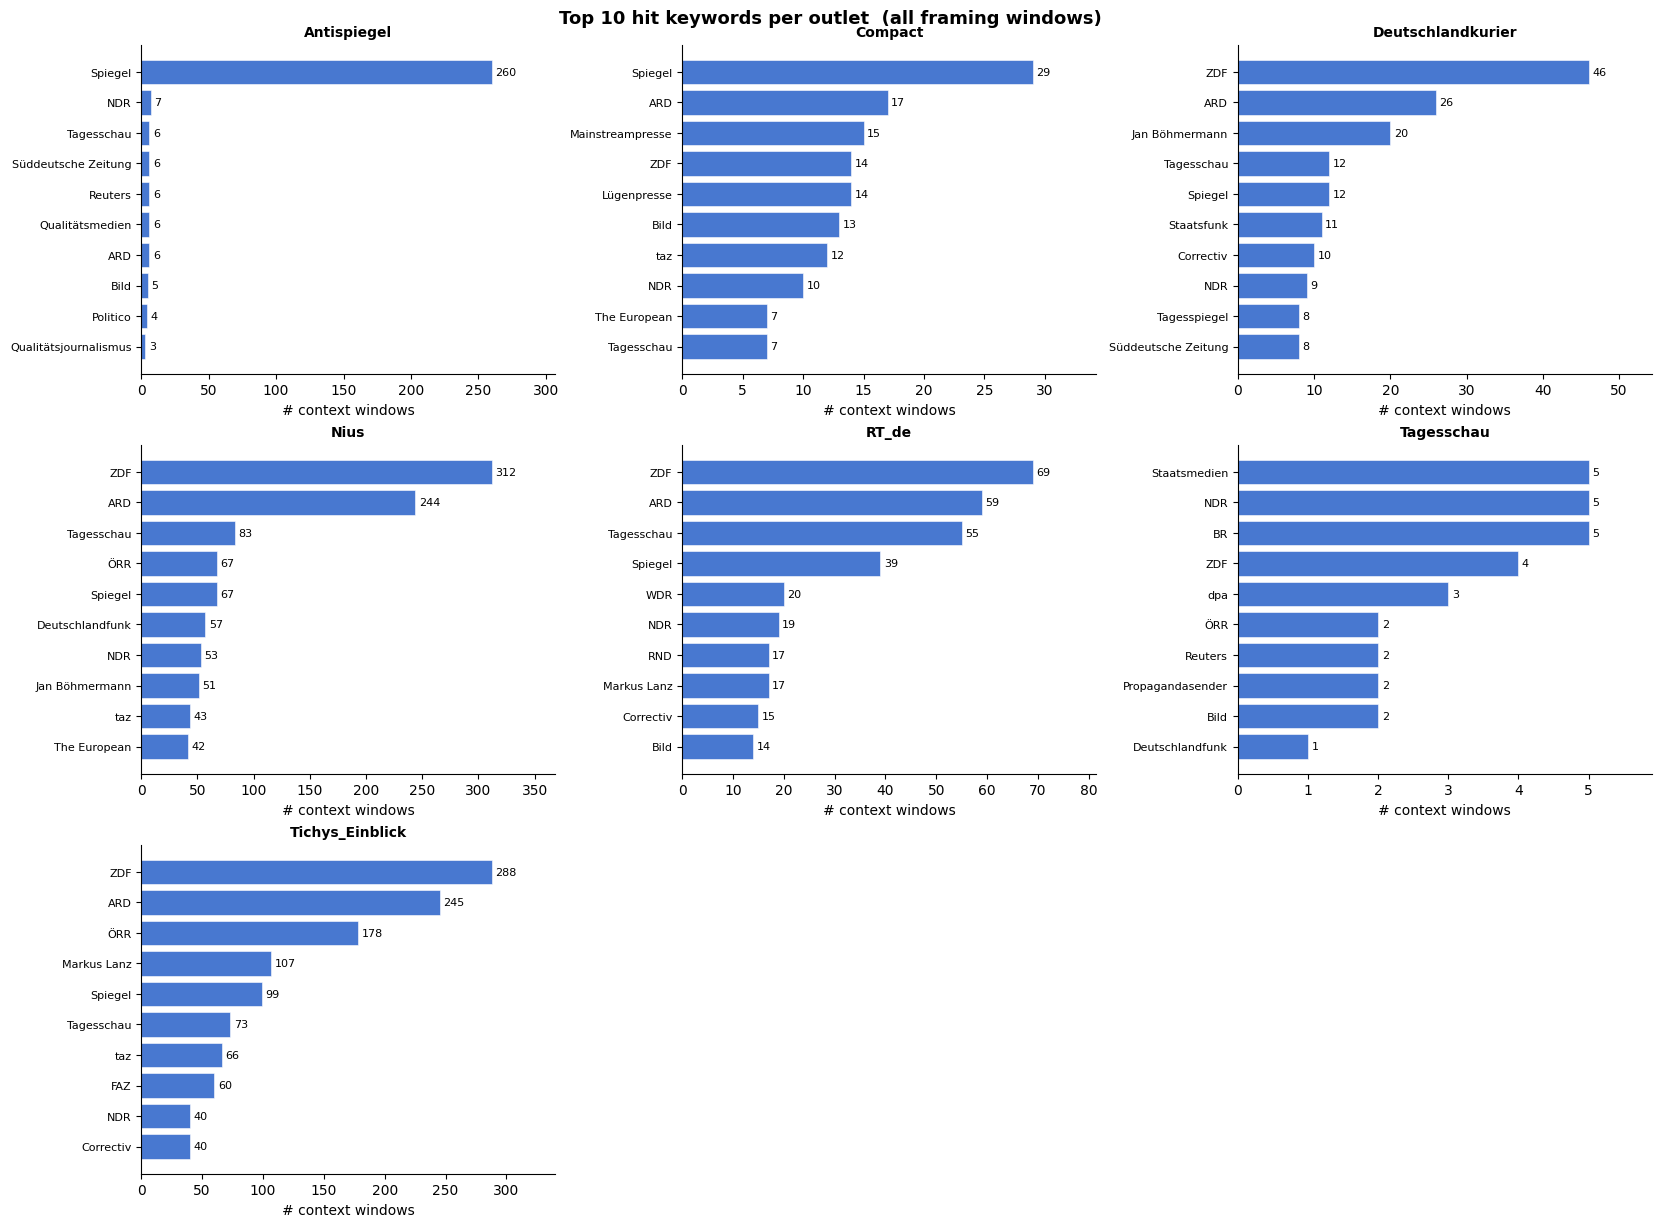

In [53]:
import math

TOP_N    = 10
SKIP_CAT = {"NEUTRAL", "IRRELEVANT"}

# Count hit_text occurrences per outlet — NEUTRAL & IRRELEVANT excluded
hit_counts = (
    df[~df["category"].isin(SKIP_CAT)].groupby(["source", "hit_text"])
    .size()
    .reset_index(name="n")
)

outlets = sorted(df["source"].unique())
ncols   = 3
nrows   = math.ceil(len(outlets) / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5.5, nrows * 4),
                         constrained_layout=True)
axes = axes.flatten()

for ax, outlet in zip(axes, outlets):
    top = (
        hit_counts[hit_counts["source"] == outlet]
        .nlargest(TOP_N, "n")
        .sort_values("n")            # ascending so largest bar is at top
    )
    ax.barh(top["hit_text"], top["n"], color="#4878d0", edgecolor="white", linewidth=0.4)
    for i, (val, label) in enumerate(zip(top["n"], top["hit_text"])):
        ax.text(val + top["n"].max() * 0.01, i, str(val),
                va="center", fontsize=8)
    ax.set_title(outlet, fontweight="bold", fontsize=10)
    ax.set_xlabel("# context windows")
    ax.set_xlim(0, top["n"].max() * 1.18)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Hide unused axes
for ax in axes[len(outlets):]:
    ax.set_visible(False)

fig.suptitle(f"Top {TOP_N} hit keywords per outlet  (all framing windows)",
             fontsize=13, fontweight="bold", y=1.01)
plt.show()


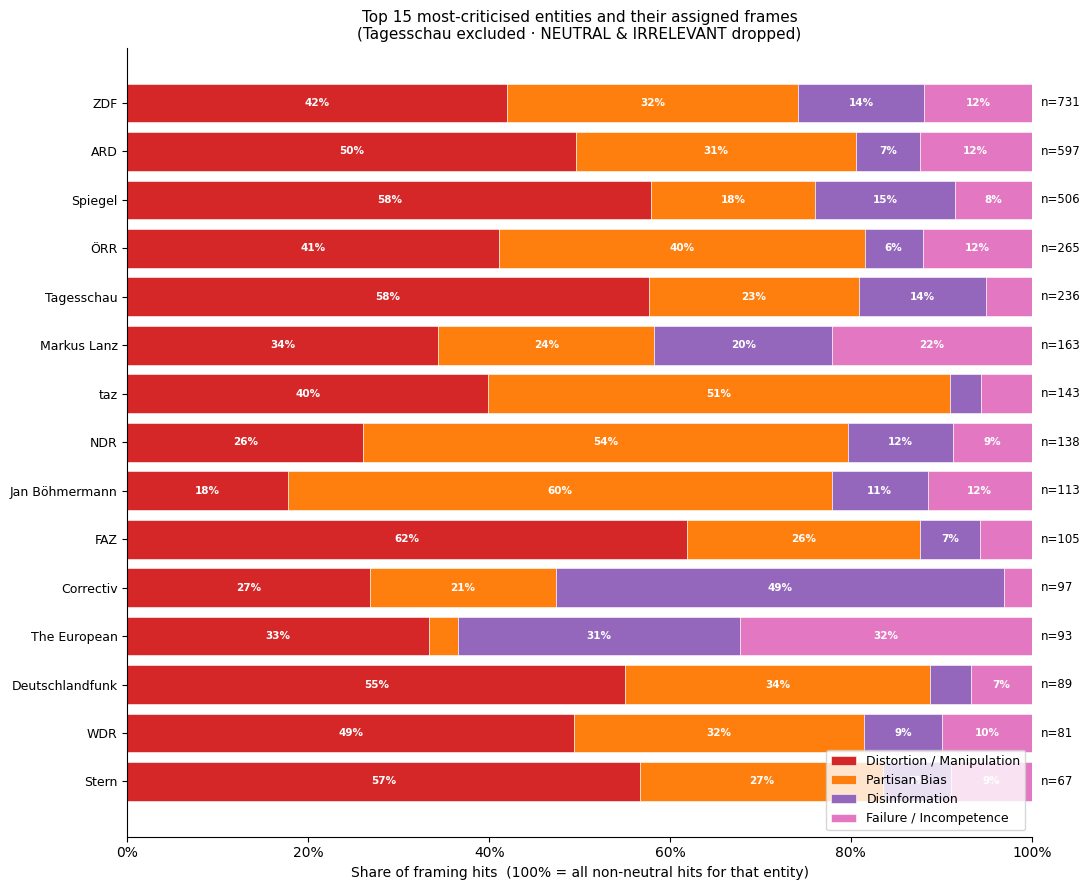

In [54]:
TOP_N = 15

# Filter: no Tagesschau, no NEUTRAL / IRRELEVANT
df_frame = df[
    (df["source"] != "Tagesschau") &
    (~df["category"].isin({"NEUTRAL", "IRRELEVANT"}))
].copy()
df_frame["category_en"] = df_frame["category"].map(CATEGORY_EN)

# Top N hit_text by total framing hit count
top_hits = (
    df_frame.groupby("hit_text").size()
    .nlargest(TOP_N)
    .index.tolist()
)

# Pivot: hit_text × English frame category
pivot = (
    df_frame[df_frame["hit_text"].isin(top_hits)]
    .groupby(["hit_text", "category_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FRAMING_COLS, fill_value=0)
)
# Ascending sort so largest bar sits at top of horizontal chart
totals = pivot.sum(axis=1)
pivot  = pivot.loc[totals.sort_values().index]
totals = totals.reindex(pivot.index)
# Normalise each row to 100%
pct = pivot.div(totals, axis=0) * 100

fig, ax = plt.subplots(figsize=(11, max(5, len(pivot) * 0.6)))

lefts = np.zeros(len(pct))
for frame in FRAMING_COLS:
    vals = pct[frame].values
    ax.barh(pct.index, vals, left=lefts, color=COLORS[frame],
            label=frame, edgecolor="white", linewidth=0.4)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 6:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    fontsize=7.5, color="white", fontweight="bold")
    lefts += vals

# Raw count at bar end
for i, (_, n) in enumerate(totals.items()):
    ax.text(101, i, f"n={int(n)}", va="center", fontsize=8.5)

ax.set_xlabel("Share of framing hits  (100% = all non-neutral hits for that entity)")
ax.set_title(
    f"Top {TOP_N} most-criticised entities and their assigned frames\n"
    "(Tagesschau excluded · NEUTRAL & IRRELEVANT dropped)",
    fontsize=11
)
ax.legend(loc="lower right", frameon=True, fontsize=9)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


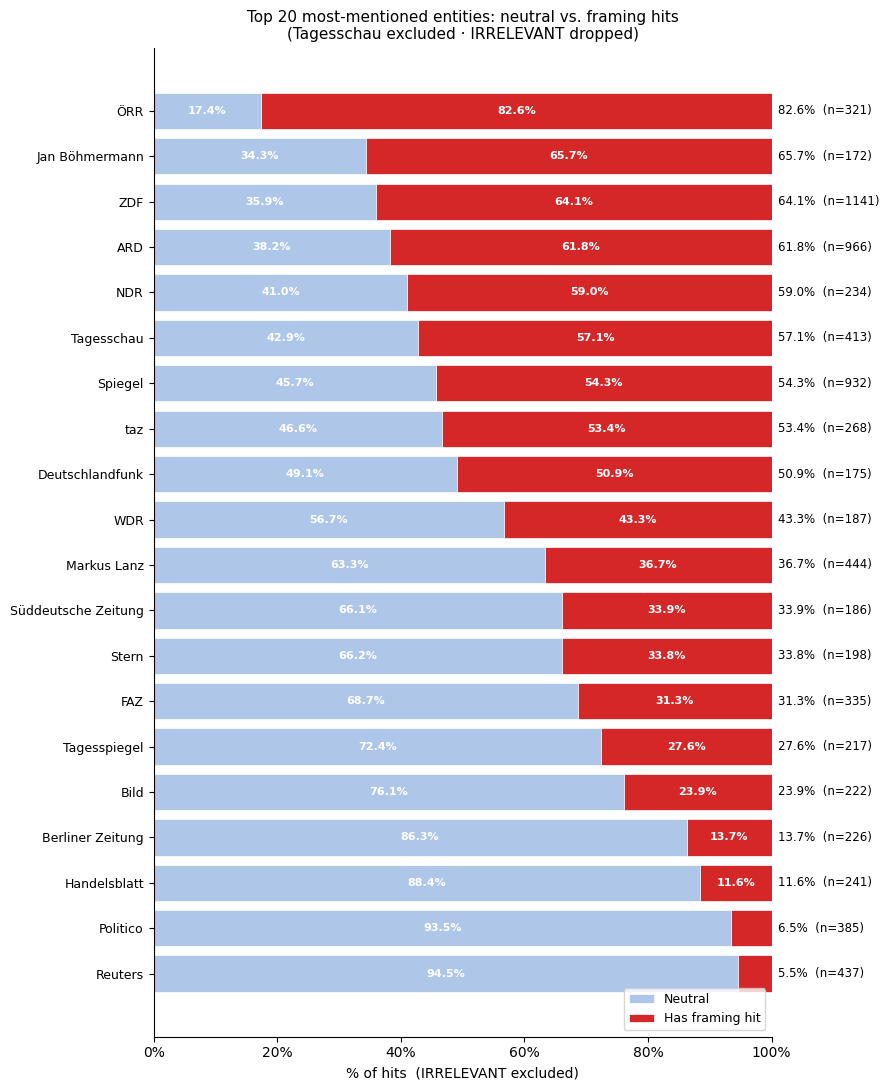

In [58]:
TOP_N = 20  # top entities by total (non-irrelevant) hits

# Exclude Tagesschau and IRRELEVANT
df_hits = df[
    (df["source"] != "Tagesschau") &
    (df["category"] != "IRRELEVANT")
].copy()

# Label each hit as Neutral or Framing
df_hits["label"] = df_hits["category"].apply(
    lambda c: "Neutral" if c == "NEUTRAL" else "Has framing hit"
)

# Total hits per entity → pick top N
top_entities = (
    df_hits.groupby("hit_text").size()
    .nlargest(TOP_N)
    .index.tolist()
)

df_top = df_hits[df_hits["hit_text"].isin(top_entities)]

# Pivot: entity × label
pivot = (
    df_top.groupby(["hit_text", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Neutral", "Has framing hit"], fill_value=0)
)

totals = pivot.sum(axis=1)
pct    = pivot.div(totals, axis=0) * 100

# Sort: highest framing rate at top
pct    = pct.loc[pct["Has framing hit"].sort_values().index]
totals = totals.reindex(pct.index)

COLORS_NF = {"Neutral": "#aec6e8", "Has framing hit": "#d62728"}

fig, ax = plt.subplots(figsize=(9, max(5, len(pct) * 0.55)))

lefts = np.zeros(len(pct))
for col in ["Neutral", "Has framing hit"]:
    vals = pct[col].values
    ax.barh(pct.index, vals, left=lefts,
            color=COLORS_NF[col], label=col, edgecolor="white", linewidth=0.5)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 8:
            ax.text(l + v / 2, i, f"{v:.1f}%",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    lefts += vals

# Framing % + n= at bar end
for i, (entity, n) in enumerate(totals.items()):
    fp = pct.loc[entity, "Has framing hit"]
    ax.text(101, i, f"{fp:.1f}%  (n={int(n)})", va="center", fontsize=8.5)

ax.set_xlabel("% of hits  (IRRELEVANT excluded)", fontsize=10)
ax.set_title(
    f"Top {TOP_N} most-mentioned entities: neutral vs. framing hits\n"
    "(Tagesschau excluded · IRRELEVANT dropped)",
    fontsize=11
)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


In [55]:
df.info()

<class 'pandas.DataFrame'>
Index: 14702 entries, 0 to 11974
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   hit_id                 14702 non-null  str  
 1   row_id                 14702 non-null  int64
 2   source                 14702 non-null  str  
 3   Title                  14702 non-null  str  
 4   hit_text               14702 non-null  str  
 5   context_idx            14702 non-null  int64
 6   count_hits             14702 non-null  int64
 7   count_unique_entities  14702 non-null  int64
 8   context_window         14702 non-null  str  
 9   model                  14702 non-null  str  
 10  response_id            14702 non-null  str  
 11  category               14702 non-null  str  
 12  evidence               4364 non-null   str  
 13  raw_response_json      14702 non-null  str  
dtypes: int64(4), str(10)
memory usage: 1.7 MB
